In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def find_file(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the same folder as this notebook."
    )

details_path = find_file("order_details.csv")
timestamps_path = find_file("order_timestamp.csv")

details = pd.read_csv(details_path)
timestamps = pd.read_csv(timestamps_path)

print("order_details shape:", details.shape)
print("order_timestamp shape:", timestamps.shape)


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ohkh1d6a because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


order_details shape: (151803, 10)
order_timestamp shape: (151803, 4)


In [2]:
for col in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[col] = pd.to_datetime(timestamps[col], errors="coerce")

df = details.merge(
    timestamps[["order_id", "start_time_slot", "accept_time", "arrived_pickup_at"]],
    on="order_id",
    how="left",
    validate="one_to_one"
)

df["BATR_raw_min"] = (
    df["arrived_pickup_at"] - df["start_time_slot"]
).dt.total_seconds() / 60

df["BATR_min"] = df["BATR_raw_min"].clip(lower=0)

df["BATR15"] = np.where(
    df["BATR_min"].notna(),
    (df["BATR_min"] <= 15).astype(int),
    np.nan
)

valid = df[df["BATR15"].notna()].copy()
valid["BATR15"] = valid["BATR15"].astype(int)

print(f"Total orders: {len(df):,}")
print(f"Orders with valid BATR: {len(valid):,}")
print(f"Missing/invalid BATR: {df['BATR15'].isna().sum():,}")
print(f"Raw negative BATR values set to zero: {(df['BATR_raw_min'] < 0).sum():,}")
print(f"Overall BATR15=1: {valid['BATR15'].mean()*100:.2f}%")


Total orders: 151,803
Orders with valid BATR: 151,582
Missing/invalid BATR: 221
Raw negative BATR values set to zero: 23,805
Overall BATR15=1: 77.45%


In [3]:
city_counts = (
    valid.groupby(["order_city", "BATR15"])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=[0, 1], fill_value=0)
)

city_pct = city_counts.div(city_counts.sum(axis=1), axis=0) * 100

city_summary = pd.DataFrame({
    "Orders": city_counts.sum(axis=1),
    "BATR15 = 0 (%)": city_pct[0],
    "BATR15 = 1 (%)": city_pct[1],
}).sort_index()

city_summary


,Orders,BATR15 = 0 (%),BATR15 = 1 (%)
order_city,,,
B,21326,9.69,90.31
K,78888,27.57,72.43
U,51368,20.17,79.83


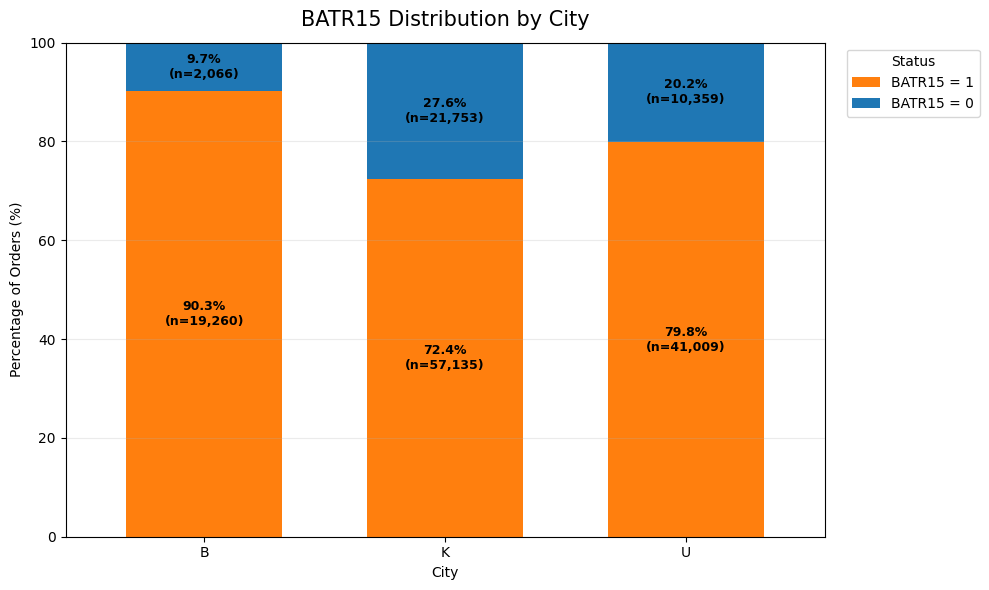

In [4]:
def add_stacked_percent_labels(ax, pct_df, count_df):

    for i, idx in enumerate(pct_df.index):
        bottom = 0
        for col in pct_df.columns:
            pct = float(pct_df.loc[idx, col])
            n = int(count_df.loc[idx, col])


            y = bottom + pct / 2
            ax.text(
                i,
                y,
                f"{pct:.1f}%\n(n={n:,})",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )
            bottom += pct





plot_df = city_pct[[1, 0]].copy()
plot_counts = city_counts[[1, 0]].copy()

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.65,
    color=["tab:orange", "tab:blue"]
)

add_stacked_percent_labels(ax, plot_df, plot_counts)

ax.set_title("BATR15 Distribution by City", fontsize=15, pad=12)
ax.set_xlabel("City")
ax.set_ylabel("Percentage of Orders (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(
    ["BATR15 = 1", "BATR15 = 0"],
    title="Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
district_counts = (
    valid.groupby(["order_city", "district", "BATR15"])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=[0, 1], fill_value=0)
)

district_pct = district_counts.div(district_counts.sum(axis=1), axis=0) * 100

district_summary = district_counts.copy()
district_summary.columns = ["BATR15_0_Count", "BATR15_1_Count"]
district_summary["Orders"] = district_summary.sum(axis=1)
district_summary["BATR15 = 0 (%)"] = district_pct[0]
district_summary["BATR15 = 1 (%)"] = district_pct[1]

district_summary = district_summary[
    ["Orders", "BATR15_0_Count", "BATR15_1_Count",
     "BATR15 = 0 (%)", "BATR15 = 1 (%)"]
]

district_summary


Orders  BATR15_0_Count  ...  BATR15 = 0 (%)  BATR15 = 1 (%)
order_city district                          ...                                
B          3720        9461             671  ...            7.09           92.91
           3724        3452             234  ...            6.78           93.22
           3728        1624             278  ...           17.12           82.88
           3732        2181             202  ...            9.26           90.74
           3740        4543             674  ...           14.84           85.16
           3752          65               7  ...           10.77           89.23
K          1468        3989             672  ...           16.85           83.15
           1472          25              15  ...           60.00           40.00
           1476        3259             932  ...           28.60           71.40
           1480       26893            8018  ...           29.81           70.19
           1484        5410            1750  ...           32.35           67.65
           1488          79              43  ...           54.43           45.57
           1492          30               8  ...           26.67           73.33
           1496        1327             400  ...           30.14           69.86
           1508        8887            1709  ...           19.23           80.77
           1512       10864            3367  ...           30.99           69.01
           1520         222              85  ...           38.29           61.71
           1528        7115            2392  ...           33.62           66.38
           4176        4216            1187  ...           28.15           71.85
           4532        4797             804  ...           16.76           83.24
           4732        1775             371  ...           20.90           79.10
U          1392           5               5  ...          100.00            0.00
           1396        3469             797  ...           22.97           77.03
           1400        4162            1256  ...           30.18           69.82
           1404        4016             853  ...           21.24           78.76
           1408        2823             620  ...           21.96           78.04
           1412          10               4  ...           40.00           60.00
           1416        3149             814  ...           25.85           74.15
           1420       12031            1685  ...           14.01           85.99
           1424          14               6  ...           42.86           57.14
           1428        8576            1945  ...           22.68           77.32
           1432       13113            2374  ...           18.10           81.90

[32 rows x 5 columns]


CITY B


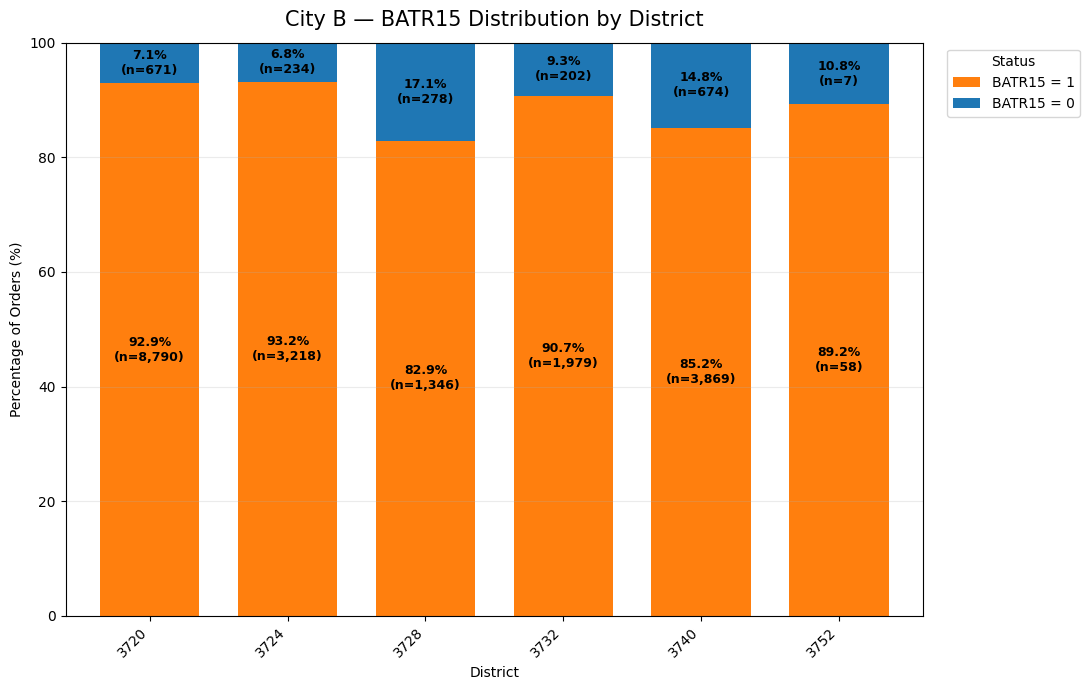

,Orders,BATR15_0_Count,BATR15_1_Count,BATR15 = 0 (%),BATR15 = 1 (%)
district,,,,,
3720,9461,671,8790,7.09,92.91
3724,3452,234,3218,6.78,93.22
3728,1624,278,1346,17.12,82.88
3732,2181,202,1979,9.26,90.74
3740,4543,674,3869,14.84,85.16
3752,65,7,58,10.77,89.23



CITY K


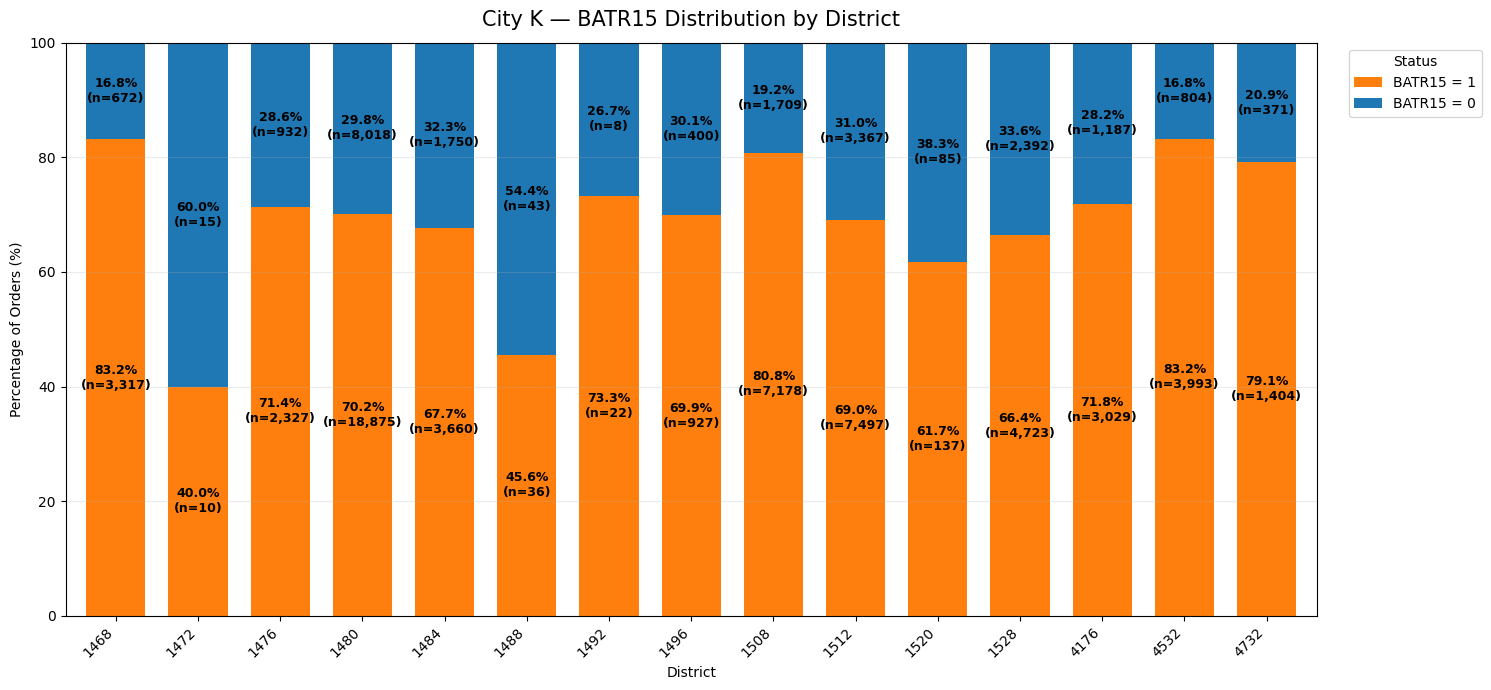

,Orders,BATR15_0_Count,BATR15_1_Count,BATR15 = 0 (%),BATR15 = 1 (%)
district,,,,,
1468,3989,672,3317,16.85,83.15
1472,25,15,10,60.00,40.00
1476,3259,932,2327,28.60,71.40
1480,26893,8018,18875,29.81,70.19
1484,5410,1750,3660,32.35,67.65
1488,79,43,36,54.43,45.57
1492,30,8,22,26.67,73.33
1496,1327,400,927,30.14,69.86
1508,8887,1709,7178,19.23,80.77



CITY U


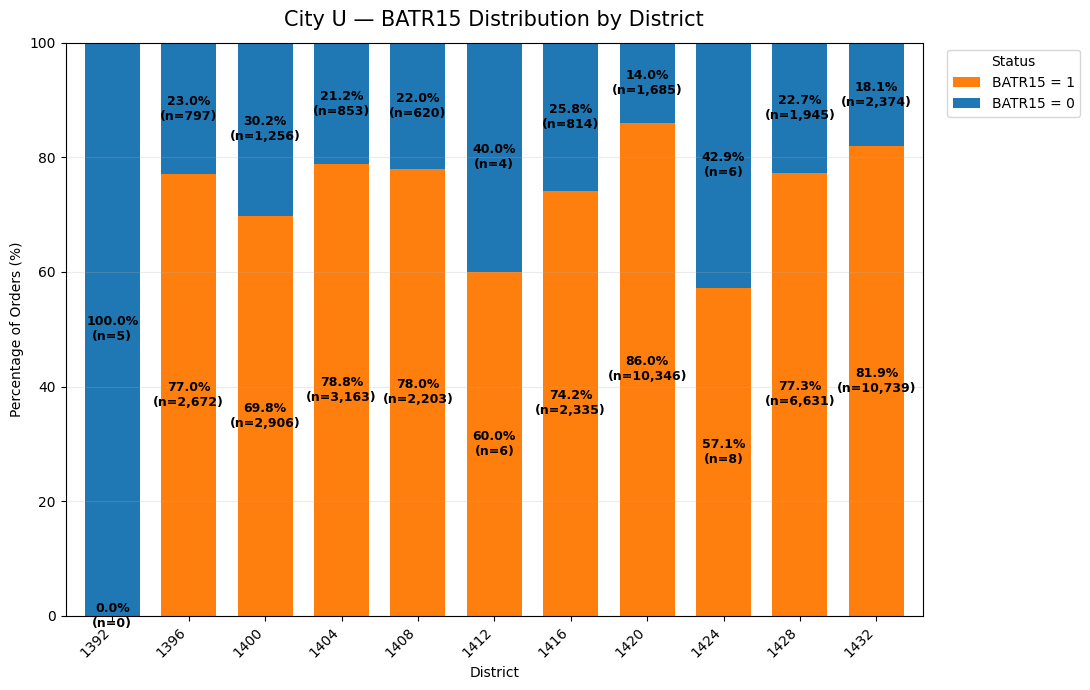

,Orders,BATR15_0_Count,BATR15_1_Count,BATR15 = 0 (%),BATR15 = 1 (%)
district,,,,,
1392,5,5,0,100.00,0.00
1396,3469,797,2672,22.97,77.03
1400,4162,1256,2906,30.18,69.82
1404,4016,853,3163,21.24,78.76
1408,2823,620,2203,21.96,78.04
1412,10,4,6,40.00,60.00
1416,3149,814,2335,25.85,74.15
1420,12031,1685,10346,14.01,85.99
1424,14,6,8,42.86,57.14


In [6]:
def plot_city_district_batr15(city):
    sub_counts = district_counts.loc[city].copy().sort_index()
    sub_pct = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 100


    plot_df = sub_pct[[1, 0]].copy()
    plot_counts = sub_counts[[1, 0]].copy()

    plot_df.index = plot_df.index.astype(str)
    plot_counts.index = plot_counts.index.astype(str)

    fig_width = max(11, len(plot_df) * 1.0)

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(fig_width, 7),
        width=0.72,
        color=["tab:orange", "tab:blue"]
    )

    add_stacked_percent_labels(ax, plot_df, plot_counts)

    ax.set_title(f"City {city} — BATR15 Distribution by District", fontsize=15, pad=12)
    ax.set_xlabel("District")
    ax.set_ylabel("Percentage of Orders (%)")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(
        ["BATR15 = 1", "BATR15 = 0"],
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    return district_summary.loc[city].copy().sort_index()

for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city}")
    print("=" * 80)
    display(plot_city_district_batr15(city))


In [7]:
ranking = (
    district_summary
    .reset_index()
    .sort_values(
        ["order_city", "BATR15 = 1 (%)"],
        ascending=[True, False]
    )
    .copy()
)

ranking["Rank within City"] = (
    ranking.groupby("order_city")["BATR15 = 1 (%)"]
           .rank(method="first", ascending=False)
           .astype(int)
)

ranking = ranking[
    [
        "order_city",
        "Rank within City",
        "district",
        "Orders",
        "BATR15_1_Count",
        "BATR15_0_Count",
        "BATR15 = 1 (%)",
        "BATR15 = 0 (%)"
    ]
]

ranking


,order_city,Rank within City,district,Orders,BATR15_1_Count,BATR15_0_Count,BATR15 = 1 (%),BATR15 = 0 (%)
1,B,1,3724,3452,3218,234,93.22,6.78
0,B,2,3720,9461,8790,671,92.91,7.09
3,B,3,3732,2181,1979,202,90.74,9.26
5,B,4,3752,65,58,7,89.23,10.77
4,B,5,3740,4543,3869,674,85.16,14.84
2,B,6,3728,1624,1346,278,82.88,17.12
19,K,1,4532,4797,3993,804,83.24,16.76
6,K,2,1468,3989,3317,672,83.15,16.85
14,K,3,1508,8887,7178,1709,80.77,19.23
20,K,4,4732,1775,1404,371,79.10,20.90
